In [ ]:
#imports all necessary features for the project as well as the two data sets or traning and testing

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

train = pd.read_parquet('C:/Users/mmont/Documents/portfolio/phase1-nlp-classifier/data/Training.parquet')
test = pd.read_parquet('C:/Users/mmont/Documents/portfolio/phase1-nlp-classifier/data/Testing.parquet')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (7658, 89)
Test shape: (3772, 89)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,https://www.todayshomeowner.com/how-to-make-ho...,82,23,0,2,7,0,0,0,0,...,1,1,0,240,8892,67860,0,1,4,legitimate
1,http://thapthan.ac.th/information/confirmation...,93,14,1,2,0,0,0,0,0,...,1,0,1,0,2996,4189860,0,1,2,phishing
2,http://app.dialoginsight.com/T/OFC4/L2S/3888/B...,121,21,1,3,0,0,0,0,0,...,1,1,0,30,2527,346022,0,1,3,phishing
3,https://www.bedslide.com,24,16,0,2,0,0,0,0,0,...,0,0,0,139,7531,1059151,0,0,4,legitimate
4,https://tabs.ultimate-guitar.com/s/sex_pistols...,73,24,0,3,1,0,0,0,0,...,0,0,0,3002,7590,635,0,1,5,legitimate


status
legitimate    3829
phishing      3829
Name: count, dtype: int64


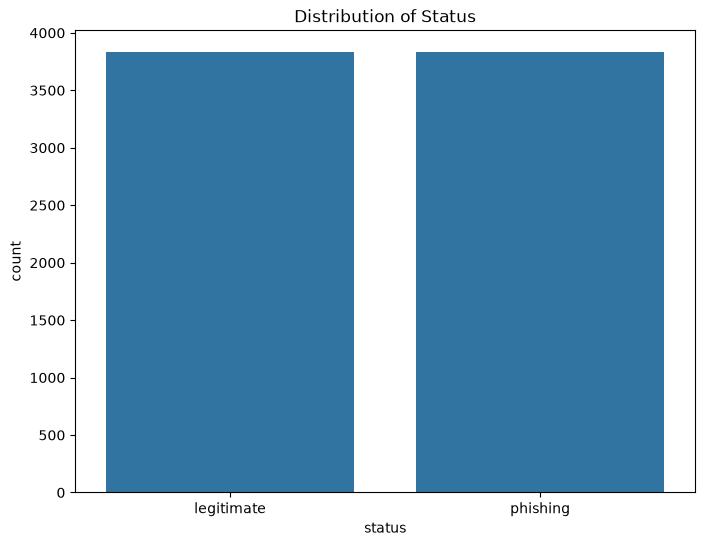

In [ ]:
#Plots the distributionj of emails that arer con sidered legitimate and those that are considered phishing. This is important to see if the data is balanced or not.

print(train['status'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='status', data=train)
plt.title('Distribution of Status')
plt.show()

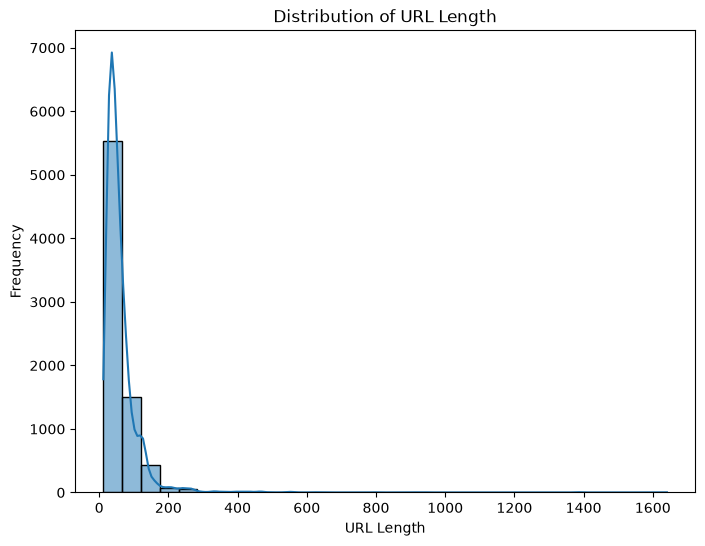

In [ ]:
# Calculates the length of each URL in the training dataset. As URLs can vary in length, this feature can be useful for classification. Longer URLs may be more likely to be phishing attempts, while shorter URLs may be more likely to be legitimate.

train['url_length'] = train['url'].apply(len)

plt.figure(figsize=(8, 6))
sns.histplot(train['url_length'], bins=30, kde=True)
plt.title('Distribution of URL Length')
plt.xlabel('URL Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Tokenizes the URLs in the training dataset and counts the frequency of each token. This can help identify common patterns or keywords that may be indicative of phishing or legitimate URLs.

def tokenize_url(url):
    return re.split(r'[\/\.\-\_\?\=\&]', url.lower())
def top_tokens(df, status, n=20):
    all_tokens = []
    for url in df[df["status"] == status]["url"]:
        all_tokens.extend([t for t in tokenize_url(url) if len(t) > 1])
    return Counter(all_tokens).most_common(n)

print("Top tokens — phishing:")
print(top_tokens(train, "phishing"))

print("\nTop tokens — legitimate:")
print(top_tokens(train, "legitimate"))

Top tokens — phishing:
[('com', 3007), ('http:', 2599), ('https:', 1294), ('www', 846), ('php', 682), ('wp', 445), ('html', 391), ('login', 359), ('cmd', 277), ('index', 255), ('update', 251), ('ap', 243), ('content', 238), ('secureupdate', 226), ('appleld', 226), ('duilawyeryork', 226), ('locale', 194), ('dispatch', 191), ('appspot', 190), ('net', 184)]

Top tokens — legitimate:
[('www', 2567), ('com', 2540), ('http:', 2128), ('https:', 1701), ('org', 383), ('html', 335), ('en', 250), ('wiki', 191), ('pdf', 163), ('wikipedia', 118), ('net', 118), ('htm', 111), ('ru', 99), ('and', 98), ('co', 94), ('blogspot', 91), ('to', 88), ('de', 88), ('the', 87), ('uk', 81)]


In [ ]:
# This section uses the TF-IDF (Term Frequency-Inverse Document Frequency) vectorization technique to convert the tokenized URLs into numerical feature vectors. 
# This is a common preprocessing step in natural language processing tasks, allowing machine learning models to work with text data.
from sklearn.feature_extraction.text import TfidfVectorizer

categorize = lambda x: ' '.join(tokenize_url(x))

# Initialize Vectorizer
vectorizer = TfidfVectorizer()

# Fit and transform the documents
tfidf_matrix = vectorizer.fit_transform(categorize(url) for url in train['url'])

print(vectorizer.get_feature_names_out())
print(tfidf_matrix.shape)

['00' '000' '0000' ... 'zzxby7xngxeopneyy' 'zzz' '拠傅']
(7658, 15278)


In [ ]:
# Extracts structured features from each URL in the dataset.

def extract_features(url):
    return pd.Series({
        "url_length": len(url),
        "digit_count": sum(c.isdigit() for c in url),
        "has_https": 1 if url.startswith("https") else 0,
        "has_ip": 1 if re.search(r'\d+\.\d+\.\d+\.\d+', url) else 0,
        "num_dots": url.count('.'),
        "num_hyphens": url.count('-'),
    })

train_struct = train['url'].apply(extract_features)
test_struct = test['url'].apply(extract_features)

In [ ]:
# Combines the TF-IDF features and the structured features into a single feature matrix for both training and testing datasets. This allows the model to leverage both types of features for classification.

from scipy.sparse import hstack

X_train = hstack([tfidf_matrix, train_struct.values])
X_test = hstack([vectorizer.transform(test['url']), test_struct.values])

y_train = train['status']
y_test = test['status']

              precision    recall  f1-score   support

  legitimate       0.90      0.92      0.91      1886
    phishing       0.92      0.90      0.91      1886

    accuracy                           0.91      3772
   macro avg       0.91      0.91      0.91      3772
weighted avg       0.91      0.91      0.91      3772



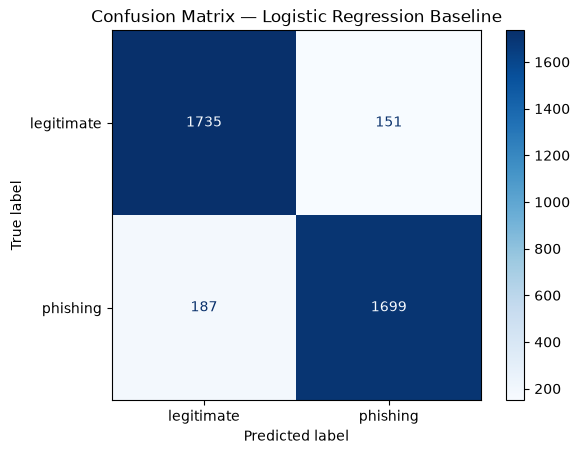

In [ ]:
# Creates a confusion matrix and classification report for the Logistic Regression model. 
# The confusion matrix provides a visual representation of the model's performance, showing the number of true positives, true negatives, false positives, and false negatives. 
# The classification report includes precision, recall, f1-score, and support for each class.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression Baseline")
plt.show()

In [ ]:
# This section initializes the DistilBERT tokenizer and model for sequence classification. 
# It converts the labels to numerical format (0 for legitimate and 1 for phishing) and tokenizes the URLs in both the training and testing datasets. The tokenized data is then prepared for input into the DistilBERT model.

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
import torch

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Convert labels to 0/1
label_map = {"legitimate": 0, "phishing": 1}
train_labels = train["status"].map(label_map).tolist()
test_labels = test["status"].map(label_map).tolist()

train_encodings = tokenizer(list(train["url"]), truncation=True, padding=True, max_length=64)
test_encodings = tokenizer(list(test["url"]), truncation=True, padding=True, max_length=64)

In [ ]:
# Defines a custom dataset class for handling URL data in PyTorch.
class URLDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = URLDataset(train_encodings, train_labels)
test_dataset = URLDataset(test_encodings, test_labels)

In [ ]:
# Sets up the training arguments and initializes the Trainer class from the Hugging Face Transformers library. The Trainer handles the training loop, evaluation, and logging for the DistilBERT model.

from transformers import Trainer, TrainingArguments

model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

training_args = TrainingArguments(
    output_dir="./distilbert_results",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    logging_steps=20,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.172559,0.154382


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\mmont\Documents\portfolio\phase1-nlp-classifier\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=479, training_loss=0.23981121337986191, metrics={'train_runtime': 2080.5031, 'train_samples_per_second': 3.681, 'train_steps_per_second': 0.23, 'total_flos': 126804417363456.0, 'train_loss': 0.23981121337986191, 'epoch': 1.0})

In [ ]:
# This trains the model and evaluates it on the test dataset, printing out a classification report that includes precision, recall, f1-score, and support for each class.

from sklearn.metrics import classification_report

preds = trainer.predict(test_dataset)
y_pred_bert = preds.predictions.argmax(axis=1)

print(classification_report(test_labels, y_pred_bert, target_names=["legitimate", "phishing"]))

              precision    recall  f1-score   support

  legitimate       0.94      0.95      0.95      1886
    phishing       0.95      0.94      0.95      1886

    accuracy                           0.95      3772
   macro avg       0.95      0.95      0.95      3772
weighted avg       0.95      0.95      0.95      3772



In [ ]:
# This creates a model and saves it to the "src" directory, along with the vectorizer used for feature extraction. The model and vectorizer can be loaded later for making predictions on new data.
import os
os.makedirs("src", exist_ok=True)

import joblib
joblib.dump(vectorizer, "src/vectorizer.pkl")
joblib.dump(clf, "src/model.pkl")

['src/model.pkl']